# EU G4 Debt-at-Risk — End-to-End Walkthrough

**Methodology:** Furceri, Giannone, Kisat, Lam & Li (May 2025), IMF WP/25/86  
**Countries:** France (FRA), Germany (DEU), Italy (ITA), Spain (ESP)  
**Horizon:** 3-year ahead (2027)  

This notebook runs the full pipeline:
1. Data pull (WEO, FSI, ECB spreads, WUI)
2. Location-scale quantile regression (MSS 2019)
3. Skewed-t distribution fitting
4. Log-score density pooling
5. Debt-at-Risk extraction (P5/P50/P95)
6. Fiscal crisis early-warning logit
7. Charts and PowerPoint deck


In [27]:
import sys, os
# Ensure project root on path
ROOT = os.path.abspath("..")
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams["figure.dpi"] = 120

print("Python:", sys.version)
print("pandas:", pd.__version__)
print("numpy:", np.__version__)


Python: 3.12.1 (main, Nov 27 2025, 10:47:52) [GCC 13.3.0]
pandas: 2.2.2
numpy: 1.26.4


## Phase 1 — Data Pipeline

Pull macro-fiscal data from IMF DataMapper API, ECB SDW, and WUI.
All data cached to `data/*.parquet` for reproducibility.


In [44]:
from data.imf_weo    import fetch_weo
from data.imf_fsi    import fetch_fsi
from data.ecb_spreads import fetch_spreads
from data.wui        import fetch_wui

print("=== WEO ===")
weo = fetch_weo(save=True)
print(f"WEO: {weo.shape[0]:,} rows, {weo['iso3'].nunique()} countries")
print(weo[weo["iso3"] == "FRA"].tail(5))


=== WEO ===
  Fetching WEO GGXWDG_NGDP …
  Fetching WEO GGXCNL_NGDP …
  Fetching WEO NGDP_RPCH …
  Fetching WEO PCPIPCH …
  Saved → /workspaces/debt_at_risk/data/weo_raw.parquet
WEO: 9,468 rows, 229 countries
     iso3  year  debt_gdp  primary_balance_gdp  rgdp_growth  cpi_inflation
3141  FRA  2020     114.9                 -8.9         -7.6            0.5
3142  FRA  2021     112.8                 -6.6          6.8            2.1
3143  FRA  2022     111.4                 -4.7          2.8            5.9
3144  FRA  2023     109.6                 -5.4          1.6            5.7
3145  FRA  2024     113.1                 -5.8          1.1            2.3


In [43]:
print("=== FSI ===")
fsi = fetch_fsi(save=True)
print(f"FSI: {fsi.shape[0]:,} rows, {fsi['iso3'].nunique()} countries")
print(fsi.head(5))


=== FSI ===
  Fetching FSI …


KeyboardInterrupt: 

In [ ]:
print("=== ECB Sovereign Spreads ===")
spreads = fetch_spreads(save=True)
print(spreads)


=== ECB Sovereign Spreads ===
  Fetching ECB 10Y sovereign yields …
    DEU (IRS/M.DE.L.L40.CI.0.EUR.N.Z) …
    FRA (IRS/M.FR.L.L40.CI.0.EUR.N.Z) …
    ITA (IRS/M.IT.L.L40.CI.0.EUR.N.Z) …
    ESP (IRS/M.ES.L.L40.CI.0.EUR.N.Z) …
  ECB API returned no spread data — using compiled historical fallback.
  Saved → /workspaces/debt_at_risk/data/ecb_spreads_raw.parquet
    iso3  year  yield_10y  spread_10y
0    DEU  1993       6.37        0.00
1    DEU  1994       6.89        0.00
2    DEU  1995       6.85        0.00
3    DEU  1996       6.24        0.00
4    DEU  1997       5.67        0.00
..   ...   ...        ...         ...
123  ITA  2020       1.22        1.79
124  ITA  2021       0.92        1.29
125  ITA  2022       3.34        2.15
126  ITA  2023       4.24        1.78
127  ITA  2024       3.89        1.51

[128 rows x 4 columns]


In [ ]:
print("=== World Uncertainty Index ===")
wui = fetch_wui(save=True)
print(f"WUI: {wui.shape[0]:,} rows, {wui['iso3'].nunique()} countries")
print(wui.head(5))


=== World Uncertainty Index ===


KeyboardInterrupt: 

In [ ]:
from data.panel_builder import build_panel

print("=== Building Estimation Panel ===")
panel = build_panel(min_obs=20)
print(panel.describe())


=== Building Estimation Panel ===
Building panel …
Panel: 7442 rows × 13 cols, 219 countries
Saved → /workspaces/debt_at_risk/data/panel.parquet
              year     debt_gdp  primary_balance_gdp  rgdp_growth  \
count  7442.000000  6331.000000          6709.000000  7399.000000   
mean   2007.346412    55.921908            -2.545282     3.442965   
std       9.957840    39.411250            11.879391     5.749021   
min    1990.000000     0.000000          -557.500000   -54.300000   
25%    1999.000000    30.600000            -4.600000     1.500000   
50%    2007.000000    48.200000            -2.500000     3.600000   
75%    2016.000000    71.100000            -0.200000     5.800000   
max    2024.000000   300.000000           125.100000   148.000000   

       cpi_inflation          fsi  spread_10y          wui  debt_gdp_lag  \
count    7326.000000  7442.000000  128.000000  7442.000000   6112.000000   
mean       10.825034     0.411085    0.820625     0.367120     55.644961   
std  

In [ ]:
# Quick QA: coverage for G4
G4 = ["FRA", "DEU", "ITA", "ESP"]
for iso3 in G4:
    sub = panel[panel["iso3"] == iso3]
    nobs = sub[["debt_gdp", "primary_balance_gdp", "rgdp_growth"]].notna().all(axis=1).sum()
    print(f"{iso3}: {nobs} complete core observations  "
          f"(debt range: {sub['debt_gdp'].min():.0f}–{sub['debt_gdp'].max():.0f}% GDP)")


FRA: 35 complete core observations  (debt range: 37–115% GDP)
DEU: 34 complete core observations  (debt range: 39–81% GDP)
ITA: 35 complete core observations  (debt range: 102–154% GDP)
ESP: 35 complete core observations  (debt range: 36–119% GDP)


### Historical Debt/GDP trajectories for G4

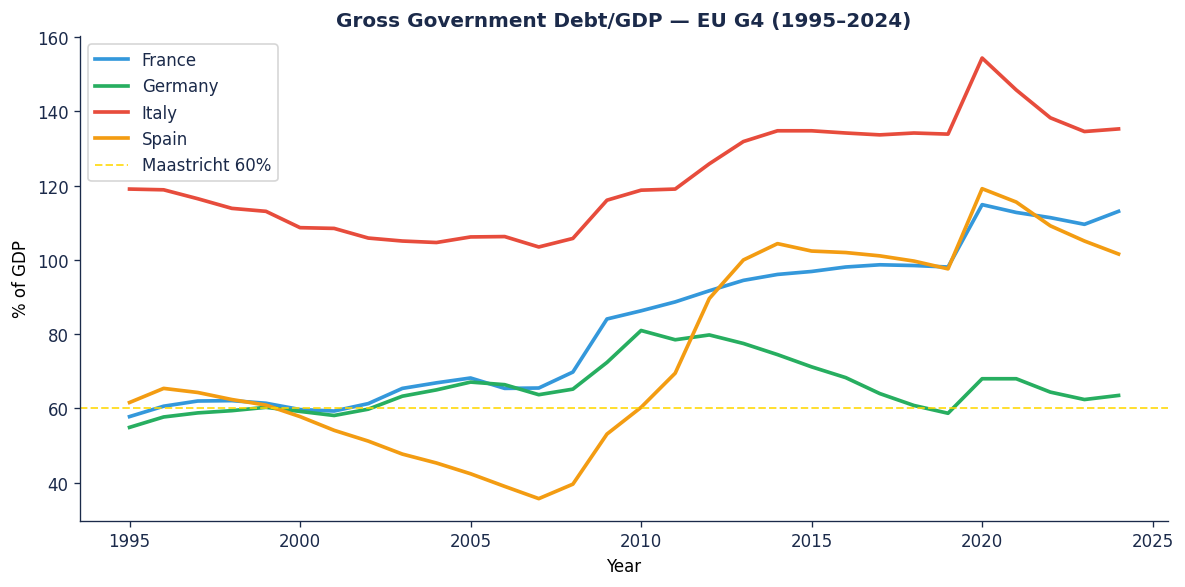

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
colors = {"FRA": "#3498DB", "DEU": "#27AE60", "ITA": "#E74C3C", "ESP": "#F39C12"}
labels = {"FRA": "France", "DEU": "Germany", "ITA": "Italy", "ESP": "Spain"}

for iso3 in G4:
    hist = panel[(panel["iso3"] == iso3) & (panel["year"] >= 1995)].sort_values("year")
    ax.plot(hist["year"], hist["debt_gdp"], lw=2.2,
            color=colors[iso3], label=labels[iso3])

ax.axhline(60, color="gold", lw=1.2, ls="--", alpha=0.8, label="Maastricht 60%")
ax.set_title("Gross Government Debt/GDP — EU G4 (1995–2024)", fontweight="bold")
ax.set_xlabel("Year"); ax.set_ylabel("% of GDP")
ax.legend(); ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.show()


## Phase 2 — Location-Scale Quantile Regression (MSS 2019)

The Machado-Santos Silva three-step estimator:

$$d_{i,t+h} = \alpha_i + X'\beta + (\delta_i + X'\gamma)\,\varepsilon_{i,t+h}$$

Three steps:
1. FE-OLS on level → residuals $\hat{e}$
2. FE-OLS on $|\hat{e}|$ → scale $\hat{s}$
3. $z = \hat{e}/\hat{s}$; empirical quantiles; predicted $Q(\tau) = \hat{\mu} + q_z(\tau)\cdot\hat{s}$


In [ ]:
from model.location_scale import run_all

print("Running MSS quantile regression (all conditioning variables × horizons) …")
print("This may take several minutes …")
qpreds = run_all(panel, horizons=[1, 3, 5])
print(f"\nQuantile predictions: {qpreds.shape[0]:,} rows")
print(qpreds.head(10))


Running MSS quantile regression (all conditioning variables × horizons) …
This may take several minutes …

  Horizon h=1:
    primary_balance … 5868 rows
    rgdp_growth … 5887 rows
    cpi_inflation … 5827 rows
    initial_debt … 5892 rows
    fsi … 5892 rows
    spread_10y … 124 rows
    wui … 5892 rows

  Horizon h=3:
    primary_balance … 5431 rows
    rgdp_growth … 5450 rows
    cpi_inflation … 5392 rows
    initial_debt … 5455 rows
    fsi … 5455 rows
    spread_10y … 116 rows
    wui … 5455 rows

  Horizon h=5:
    primary_balance … 4993 rows
    rgdp_growth … 5012 rows
    cpi_inflation … 4956 rows
    initial_debt … 5017 rows
    fsi … 5017 rows
    spread_10y … 108 rows
    wui … 5017 rows

Saved quantile predictions → /workspaces/debt_at_risk/model/quantile_predictions.parquet

Quantile predictions: 98,256 rows
  iso3  year  horizon         cond_var        Q05        Q25        Q50  \
0  ABW  1996        1  primary_balance  34.440045  48.272981  54.456526   
1  ABW  1997    

In [ ]:
# Check predictions for G4
print("Sample quantile predictions for France (h=3):")
print(qpreds[(qpreds["iso3"] == "FRA") & (qpreds["horizon"] == 3)].tail(10))


Sample quantile predictions for France (h=3):
      iso3  year  horizon cond_var        Q05        Q25        Q50  \
64504  FRA  2012        3      wui  35.602847  57.074291  69.681364   
64505  FRA  2013        3      wui  35.585708  57.711414  70.702640   
64506  FRA  2014        3      wui  36.579139  59.094249  72.314117   
64507  FRA  2015        3      wui  35.539635  58.629513  72.186859   
64508  FRA  2016        3      wui  40.505632  62.680564  75.700695   
64509  FRA  2017        3      wui  36.777000  60.029351  73.682093   
64510  FRA  2018        3      wui  37.882962  61.023017  74.609824   
64511  FRA  2019        3      wui  36.408242  59.828149  73.579273   
64512  FRA  2020        3      wui  48.526164  69.203412  81.344169   
64513  FRA  2021        3      wui  43.839874  69.187062  84.069800   

             Q75         Q95  
64504  82.222386  106.844161  
64505  83.625803  108.997835  
64506  85.464724  111.283294  
64507  85.673175  112.150845  
64508  88.652611 

## Phase 3a — Skewed-t Distribution Fitting

Fit Azzalini-Capitanio skewed-t parameters (ξ, ω, α, ν) to each set of five predicted quantiles
{Q5, Q25, Q50, Q75, Q95} via least-squares minimisation.


In [ ]:
from model.quantile_fit import fit_distributions

print("Fitting skewed-t distributions …")
skt_params = fit_distributions(qpreds)
print(f"SKT params: {skt_params.shape[0]:,} rows")
print(skt_params[skt_params["iso3"] == "FRA"].head(8))


Fitting skewed-t distributions …
  Fitting skewed-t for 16239 country×year×horizon×cond_var combinations …


KeyboardInterrupt: 

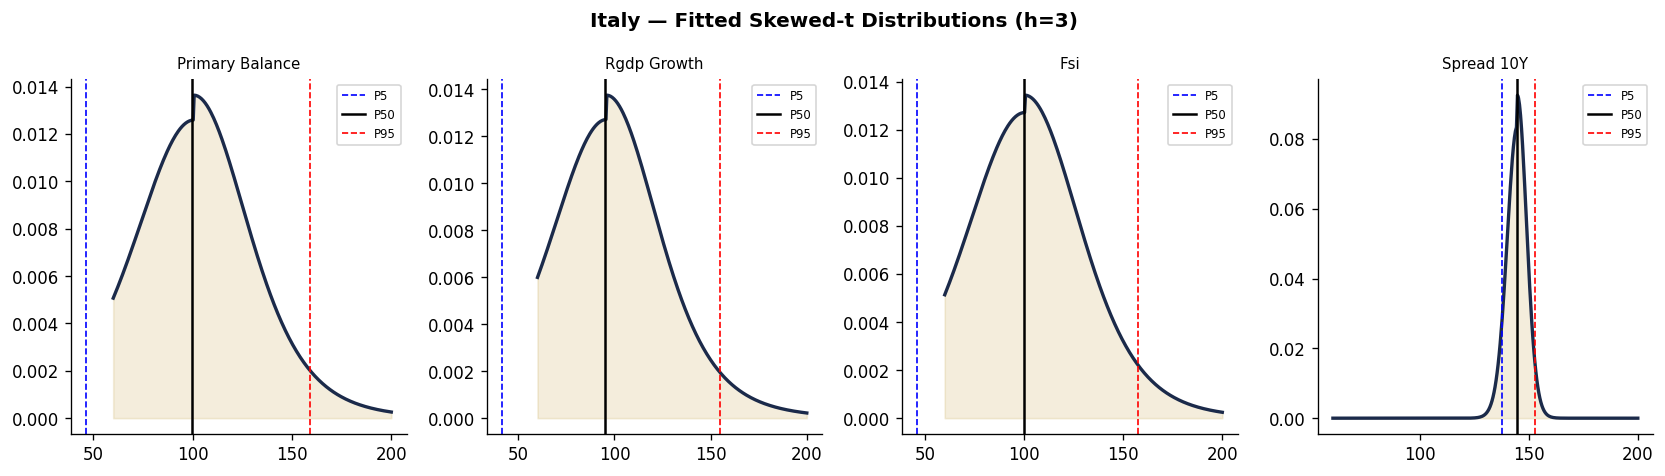

In [ ]:
# Visualise fitted distributions for Italy h=3, one conditioning variable
from model.quantile_fit import _fst_quantile
import numpy as np

fig, axes = plt.subplots(1, 4, figsize=(14, 4))
fig.suptitle("Italy — Fitted Skewed-t Distributions (h=3)", fontweight="bold")

cond_vars_show = ["primary_balance", "rgdp_growth", "fsi", "spread_10y"]
x_grid = np.linspace(60, 200, 300)

for ax, cv in zip(axes, cond_vars_show):
    sub = skt_params[
        (skt_params["iso3"] == "ITA") &
        (skt_params["horizon"] == 3) &
        (skt_params["cond_var"] == cv)
    ]
    if sub.empty: continue
    r = sub.sort_values("year").iloc[-1]
    if any(pd.isna([r["xi"], r["omega"], r["alpha"], r["nu"]])): continue

    from scipy.stats import t as t_dist
    gamma = np.exp(r["alpha"])
    omega, nu = r["omega"], r["nu"]
    xi    = r["xi"]

    def pdf(x):
        z = (x - xi) / omega
        c = 2.0 / (omega * (gamma + 1.0 / gamma))
        if z < 0:
            return c * t_dist.pdf(-z / gamma, df=nu) / gamma
        else:
            return c * t_dist.pdf(z * gamma, df=nu) * gamma

    y_pdf = np.array([pdf(xv) for xv in x_grid])
    ax.plot(x_grid, y_pdf, color="#1B2A4A", lw=2)
    ax.fill_between(x_grid, y_pdf, alpha=0.2, color="#C8A951")
    ax.axvline(_fst_quantile(0.05, xi, omega, r["alpha"], nu),
               color="blue", lw=1, ls="--", label="P5")
    ax.axvline(_fst_quantile(0.50, xi, omega, r["alpha"], nu),
               color="black", lw=1.5, ls="-", label="P50")
    ax.axvline(_fst_quantile(0.95, xi, omega, r["alpha"], nu),
               color="red", lw=1, ls="--", label="P95")
    ax.set_title(cv.replace("_", " ").title(), fontsize=9)
    ax.legend(fontsize=7)
    ax.spines[["top","right"]].set_visible(False)

plt.tight_layout()
plt.show()


## Phase 3b — Log-Score Density Pooling

Optimal mixture weights computed via rolling out-of-sample log-score maximisation
(Crump et al. 2022), country-specific, from 2005 onward.

$$w^* = \arg\max_{w\geq 0,\,\sum w=1} \sum_{t \in \text{val}} \log\left[\sum_k w_k f_k(d_{t+h}|X_t)\right]$$


In [ ]:
from risk.pooling import compute_country_weights

print("Computing log-score pooling weights (h=3) …")
weights = compute_country_weights(skt_params, panel, horizon=3)

# Show G4 weights
print("\nPooling weights for G4:")
print(weights[weights["iso3"].isin(["FRA","DEU","ITA","ESP"])]
      .pivot(index="iso3", columns="cond_var", values="weight")
      .round(3))


Computing log-score pooling weights (h=3) …
Saved pooling weights → /workspaces/debt_at_risk/risk/pooling_weights.parquet

Pooling weights for G4:
cond_var  cpi_inflation  fsi  initial_debt  primary_balance  rgdp_growth  \
iso3                                                                       
DEU                 0.0  0.0           0.0              0.0        0.086   
ESP                 0.0  0.0           0.0              0.0        0.000   
FRA                 0.0  0.0           0.0              0.0        0.000   
ITA                 0.0  0.0           0.0              0.0        0.000   

cond_var  spread_10y  wui  
iso3                       
DEU            0.914  0.0  
ESP            1.000  0.0  
FRA            1.000  0.0  
ITA            1.000  0.0  


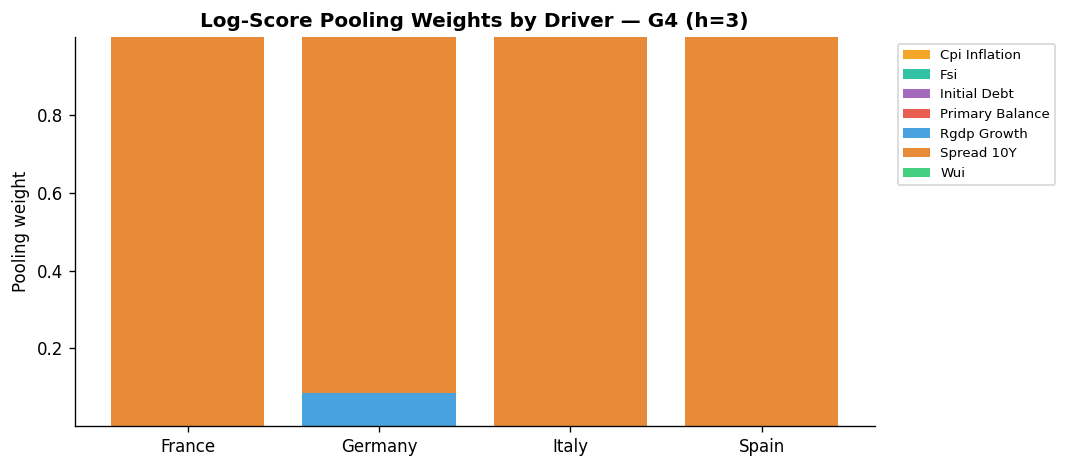

In [ ]:
# Visualise pooling weights for G4 as stacked bars
g4_w = weights[weights["iso3"].isin(G4)].pivot(
    index="iso3", columns="cond_var", values="weight"
).reindex(G4)

driver_colors = {
    "primary_balance": "#E74C3C", "rgdp_growth": "#3498DB",
    "cpi_inflation": "#F39C12",   "initial_debt": "#9B59B6",
    "fsi": "#1ABC9C", "spread_10y": "#E67E22", "wui": "#2ECC71",
}

fig, ax = plt.subplots(figsize=(9, 4))
bottom = np.zeros(4)
x = np.arange(4)
labels_g4 = [{"FRA":"France","DEU":"Germany","ITA":"Italy","ESP":"Spain"}[c] for c in G4]

for cv in g4_w.columns:
    vals = g4_w[cv].fillna(0).values
    ax.bar(x, vals, bottom=bottom, color=driver_colors.get(cv, "grey"),
           label=cv.replace("_"," ").title(), alpha=0.9)
    bottom += vals

ax.set_xticks(x); ax.set_xticklabels(labels_g4)
ax.set_ylabel("Pooling weight")
ax.set_title("Log-Score Pooling Weights by Driver — G4 (h=3)", fontweight="bold")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.show()


## Phase 3c — Debt-at-Risk (P5 / P50 / P95)

Extract quantiles from the pooled distribution. Re-center median to IMF WEO
April 2025 baseline projections for 2027.


In [ ]:
from risk.dar import compute_dar, WEO_BASELINE_2027

print("Computing Debt-at-Risk …")
dar = compute_dar(skt_params, weights, horizon=3, recenter=True)

print("\nDebt-at-Risk results:")
print(dar[["iso3","Q05","Q50","Q95","DaR","Upside","Downside","weo_baseline"]].to_string(index=False))


Computing Debt-at-Risk …
Saved DaR results → /workspaces/debt_at_risk/risk/dar_results.parquet
  iso3     Q05    Q50     Q95     DaR  Upside  Downside  weo_baseline
0  FRA  105.41  117.0  126.11  126.11    9.11     11.59         117.0
1  DEU   48.92   68.5   82.01   82.01   13.51     19.58          68.5
2  ITA  130.79  138.0  143.66  143.66    5.66      7.21         138.0
3  ESP   92.09  103.5  112.47  112.47    8.97     11.41         103.5

Debt-at-Risk results:
iso3    Q05   Q50    Q95    DaR  Upside  Downside  weo_baseline
 FRA 105.41 117.0 126.11 126.11    9.11     11.59         117.0
 DEU  48.92  68.5  82.01  82.01   13.51     19.58          68.5
 ITA 130.79 138.0 143.66 143.66    5.66      7.21         138.0
 ESP  92.09 103.5 112.47 112.47    8.97     11.41         103.5


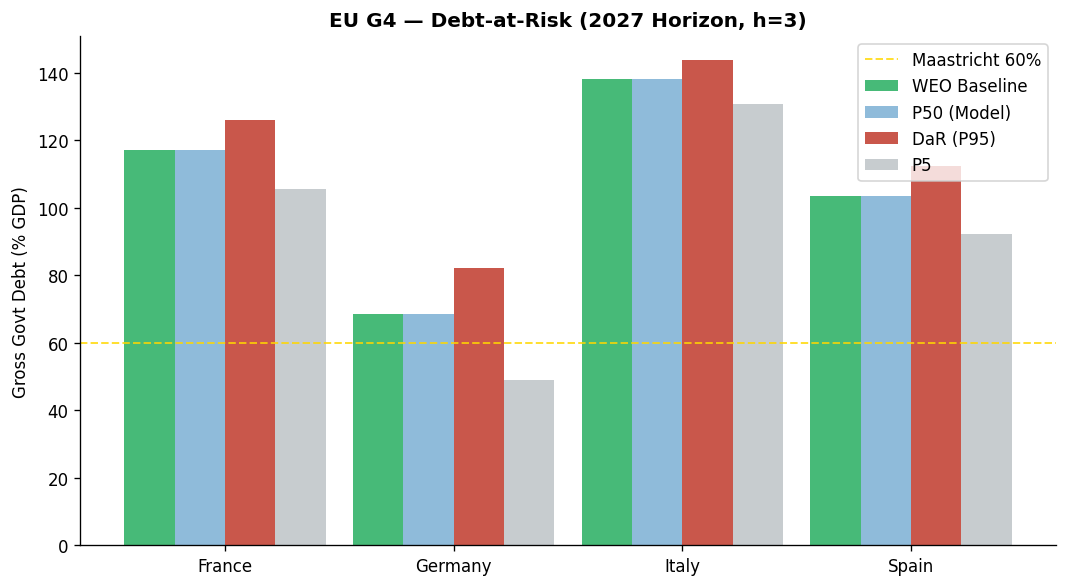

In [ ]:
# DaR summary visualisation
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(G4))
labels_g4 = ["France", "Germany", "Italy", "Spain"]
width = 0.22

q05_vals = [dar[dar["iso3"]==c]["Q05"].values[0] if not dar[dar["iso3"]==c].empty else 0 for c in G4]
q50_vals = [dar[dar["iso3"]==c]["Q50"].values[0] if not dar[dar["iso3"]==c].empty else 0 for c in G4]
q95_vals = [dar[dar["iso3"]==c]["Q95"].values[0] if not dar[dar["iso3"]==c].empty else 0 for c in G4]
weo_vals = [WEO_BASELINE_2027.get(c, 0) for c in G4]

ax.bar(x - width*1.5, weo_vals, width, label="WEO Baseline", color="#27AE60", alpha=0.85)
ax.bar(x - width*0.5, q50_vals, width, label="P50 (Model)", color="#7BAFD4", alpha=0.85)
ax.bar(x + width*0.5, q95_vals, width, label="DaR (P95)",   color="#C0392B", alpha=0.85)
ax.bar(x + width*1.5, q05_vals, width, label="P5",          color="#BDC3C7", alpha=0.85)

ax.axhline(60, color="gold", lw=1.2, ls="--", alpha=0.8, label="Maastricht 60%")
ax.set_xticks(x); ax.set_xticklabels(labels_g4)
ax.set_ylabel("Gross Govt Debt (% GDP)")
ax.set_title("EU G4 — Debt-at-Risk (2027 Horizon, h=3)", fontweight="bold")
ax.legend(framealpha=0.8)
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.show()


## Phase 4 — Fiscal Crisis Early-Warning Logit

$$\Pr(\text{crisis}_{i,t+1,t+2}) = \Lambda\!\left(\beta_0 + \beta_1 \cdot (Q_{95} - Q_{50})_{i,t}\right)$$

Estimated separately for each conditioning variable. Binary crisis indicator from
Laeven & Valencia (2020).


In [ ]:
from crisis.logit_signal import run_logit

print("Running fiscal crisis logit models …")
crisis_out = run_logit(skt_params, panel, horizon=3, forecast_years=[2025, 2026])

print("\nLogit results summary:")
for cv, res in crisis_out["logit_results"].items():
    coef_upside = res.params[1] if len(res.params) > 1 else float("nan")
    pval        = res.pvalues[1] if len(res.pvalues) > 1 else float("nan")
    print(f"  {cv:20s}  β_upside = {coef_upside:+.4f}  (p={pval:.3f})")


Running fiscal crisis logit models …
Saved crisis scores → /workspaces/debt_at_risk/crisis/crisis_scores.parquet

Logit results summary:
  primary_balance       β_upside = -0.0359  (p=0.013)
  rgdp_growth           β_upside = -0.0517  (p=0.001)
  cpi_inflation         β_upside = -0.0474  (p=0.004)
  initial_debt          β_upside = -0.0473  (p=0.003)
  fsi                   β_upside = -0.0492  (p=0.002)
  spread_10y            β_upside = +0.5863  (p=0.018)
  wui                   β_upside = -0.0470  (p=0.003)



G4 Fiscal Crisis Probability Scores:
iso3  year  crisis_prob_pooled
 DEU  2025            0.049787
 DEU  2026            0.049787
 ESP  2025            0.024191
 ESP  2026            0.024191
 FRA  2025            0.025556
 FRA  2026            0.025556
 ITA  2025            0.014716
 ITA  2026            0.014716


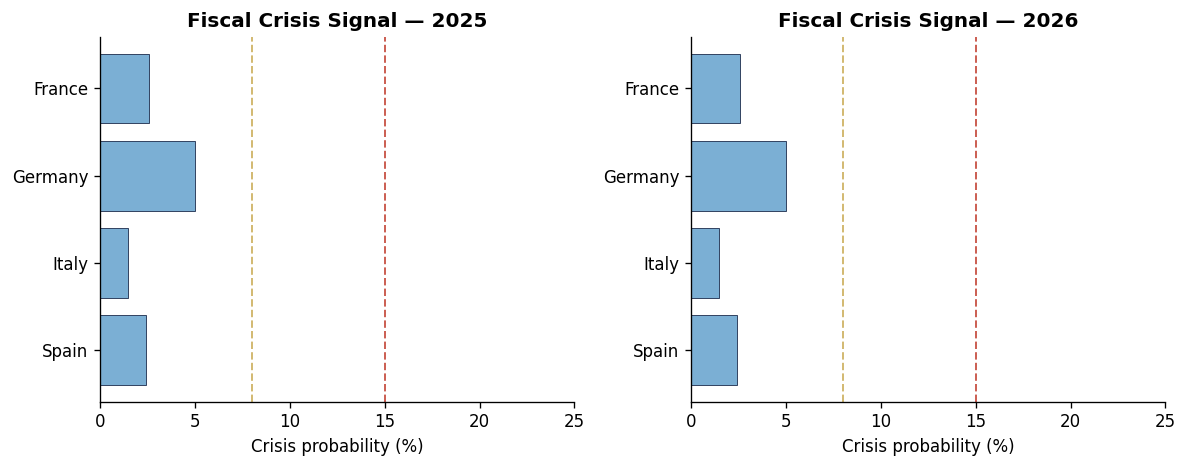

In [ ]:
# G4 crisis probability scores
pooled = crisis_out["pooled_scores"]
print("\nG4 Fiscal Crisis Probability Scores:")
print(pooled[pooled["iso3"].isin(G4)].to_string(index=False))

# Bar chart
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, yr in zip(axes, [2025, 2026]):
    sub = pooled[(pooled["iso3"].isin(G4)) & (pooled["year"] == yr)].copy()
    if sub.empty:
        ax.set_title(str(yr))
        continue
    sub = sub.set_index("iso3").reindex(G4)
    probs = sub["crisis_prob_pooled"].fillna(0).values * 100
    labels_g4 = ["France", "Germany", "Italy", "Spain"]
    bar_colors = ["#C0392B" if p > 15 else "#C8A951" if p > 8 else "#7BAFD4"
                  for p in probs]
    ax.barh(labels_g4, probs, color=bar_colors, edgecolor="#1B2A4A", linewidth=0.5)
    ax.axvline(8,  color="#C8A951", lw=1.2, ls="--", alpha=0.8)
    ax.axvline(15, color="#C0392B", lw=1.2, ls="--", alpha=0.8)
    ax.set_xlabel("Crisis probability (%)")
    ax.set_title(f"Fiscal Crisis Signal — {yr}", fontweight="bold")
    ax.set_xlim(0, max(probs.max() + 5, 25))
    ax.spines[["top","right"]].set_visible(False)
    ax.invert_yaxis()
plt.tight_layout()
plt.show()


## Phase 5 — Generate All Charts

In [ ]:
from output.charts import generate_all_charts

chart_paths = generate_all_charts(panel, dar, skt_params, pooled)
for name, path in chart_paths.items():
    print(f"  {name}: {path}")


Generating charts …
  Saved → /workspaces/debt_at_risk/output/fig0_global_context.png
  Saved → /workspaces/debt_at_risk/output/fig1_fan_charts.png
  Saved → /workspaces/debt_at_risk/output/fig2_comparison_bar.png
  Saved → /workspaces/debt_at_risk/output/fig3_waterfall.png
  Saved → /workspaces/debt_at_risk/output/fig4_crisis_signal.png
  global_context: /workspaces/debt_at_risk/output/fig0_global_context.png
  fan_charts: /workspaces/debt_at_risk/output/fig1_fan_charts.png
  comparison_bar: /workspaces/debt_at_risk/output/fig2_comparison_bar.png
  waterfall: /workspaces/debt_at_risk/output/fig3_waterfall.png
  crisis_signal: /workspaces/debt_at_risk/output/fig4_crisis_signal.png


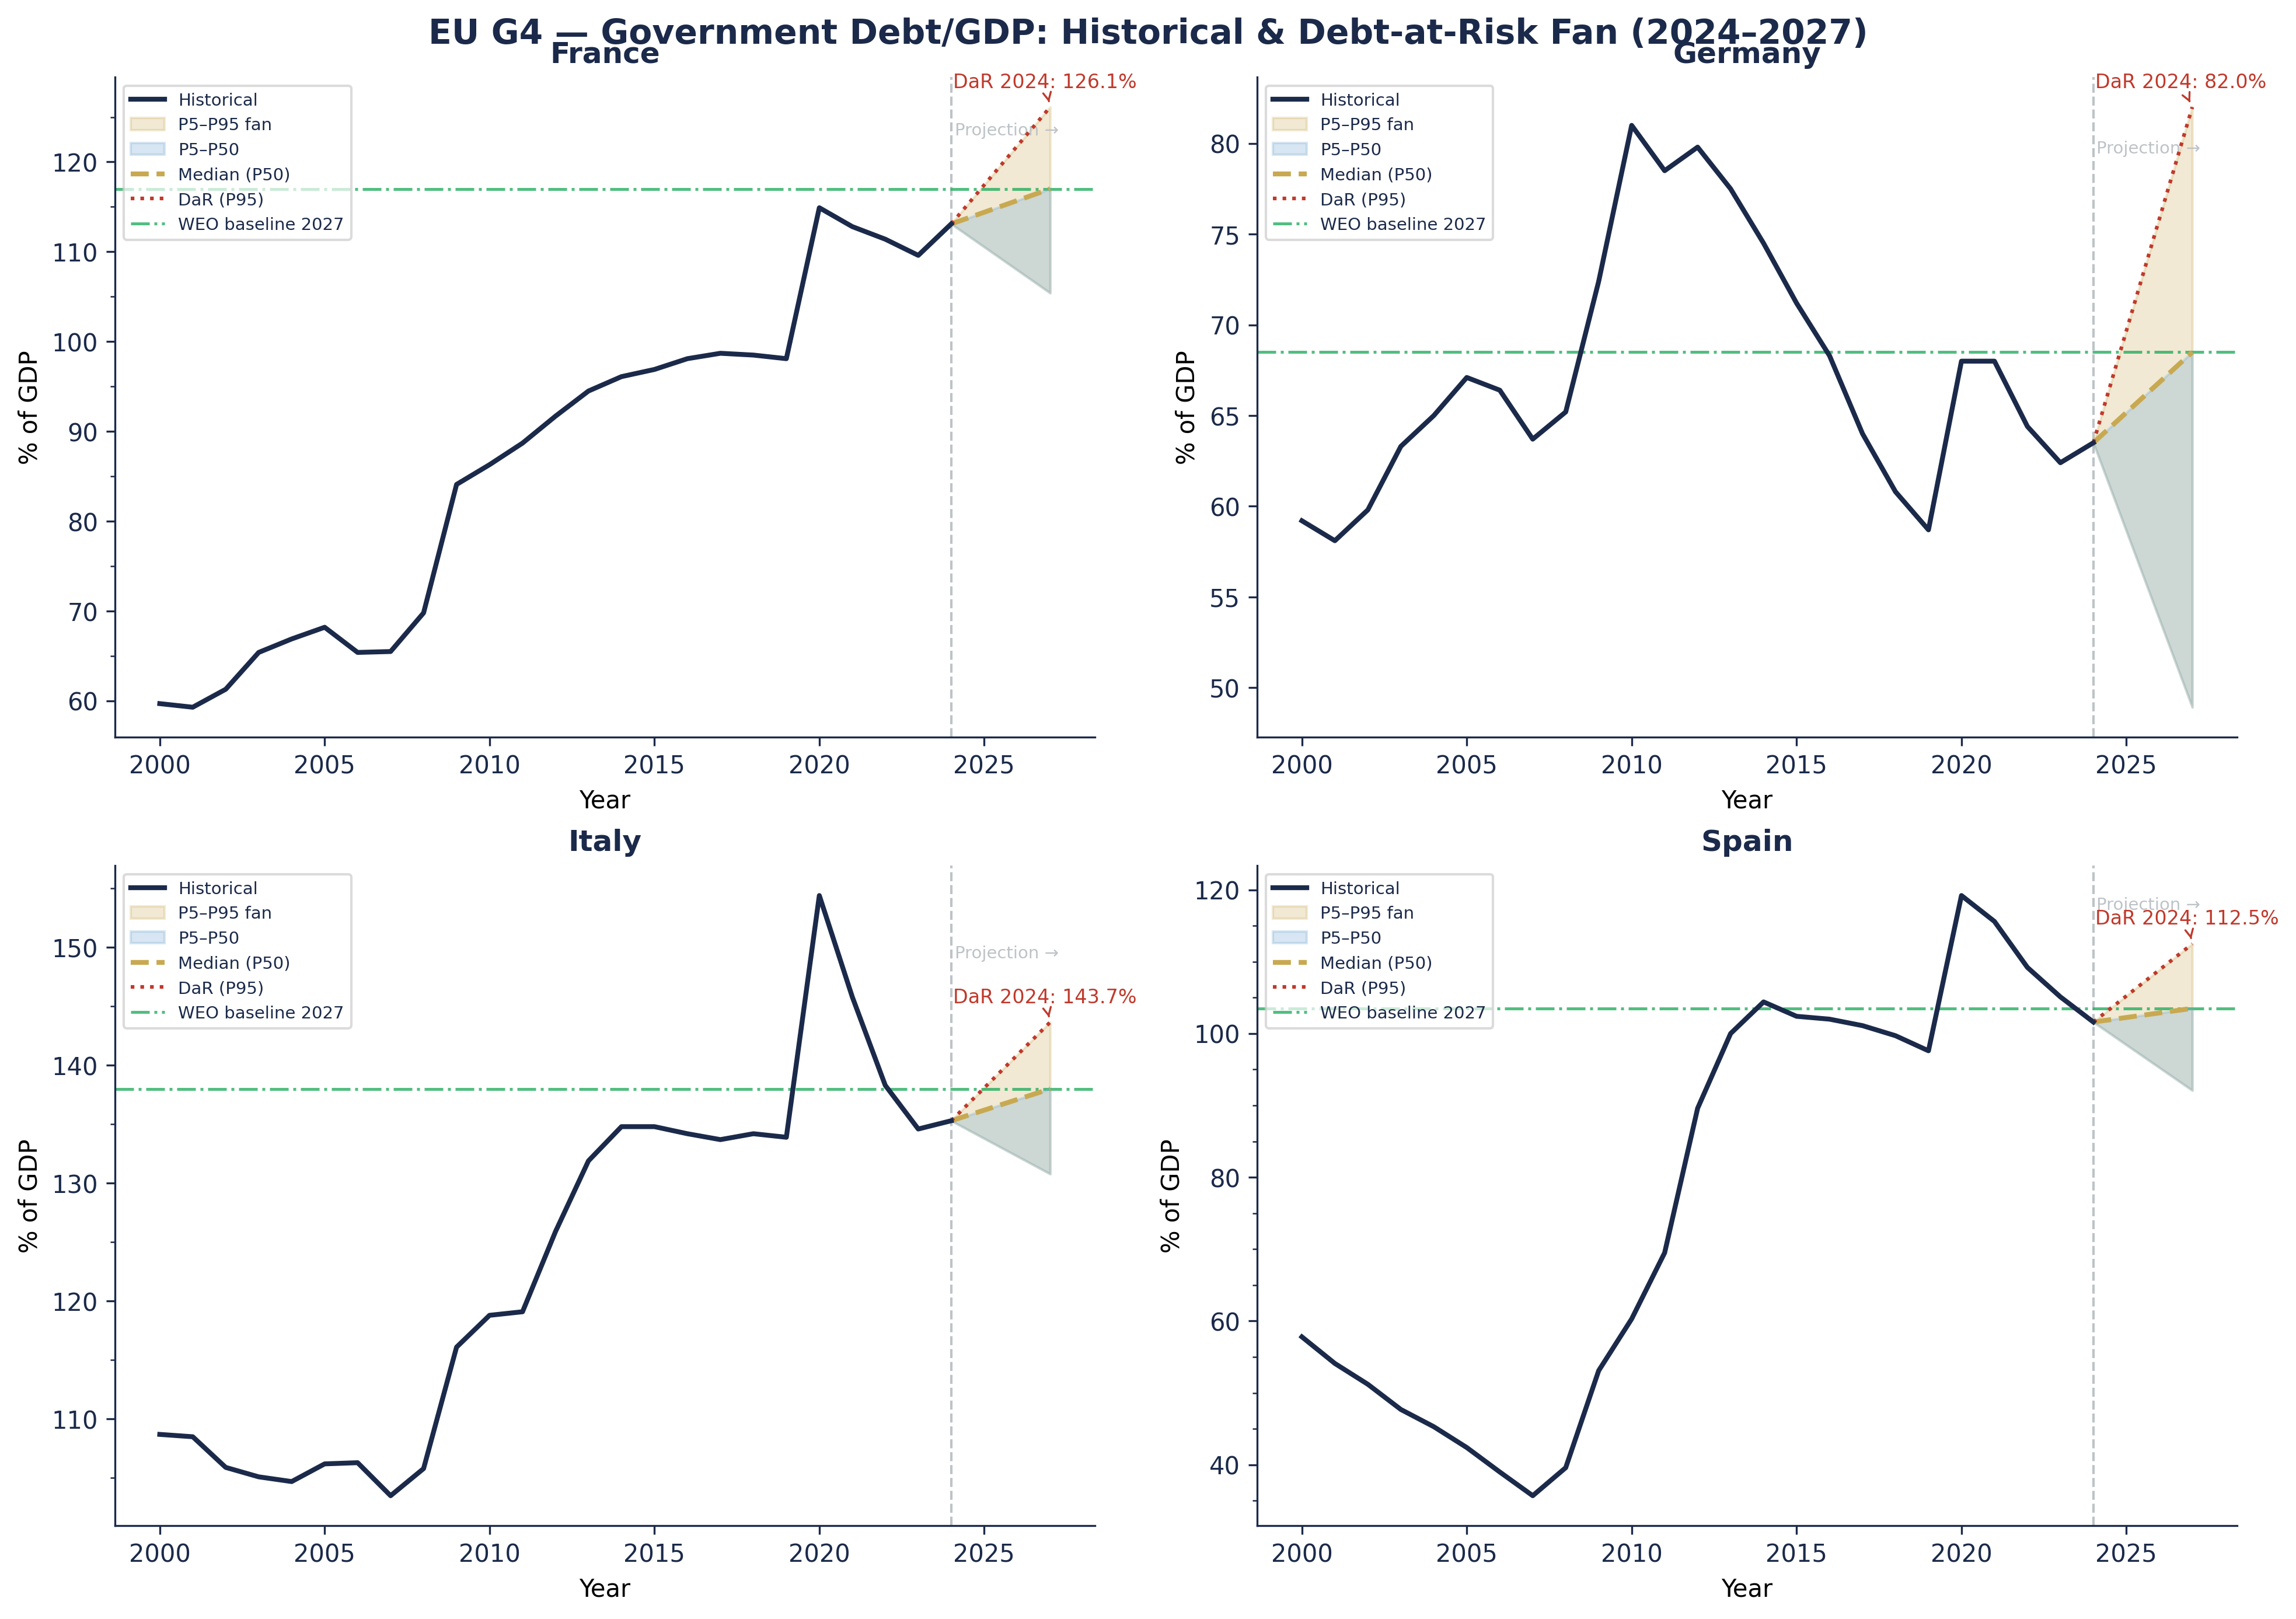

In [ ]:
# Display fan charts inline
from IPython.display import Image, display
fan_path = chart_paths.get("fan_charts")
if fan_path and fan_path.exists():
    display(Image(filename=str(fan_path), width=950))


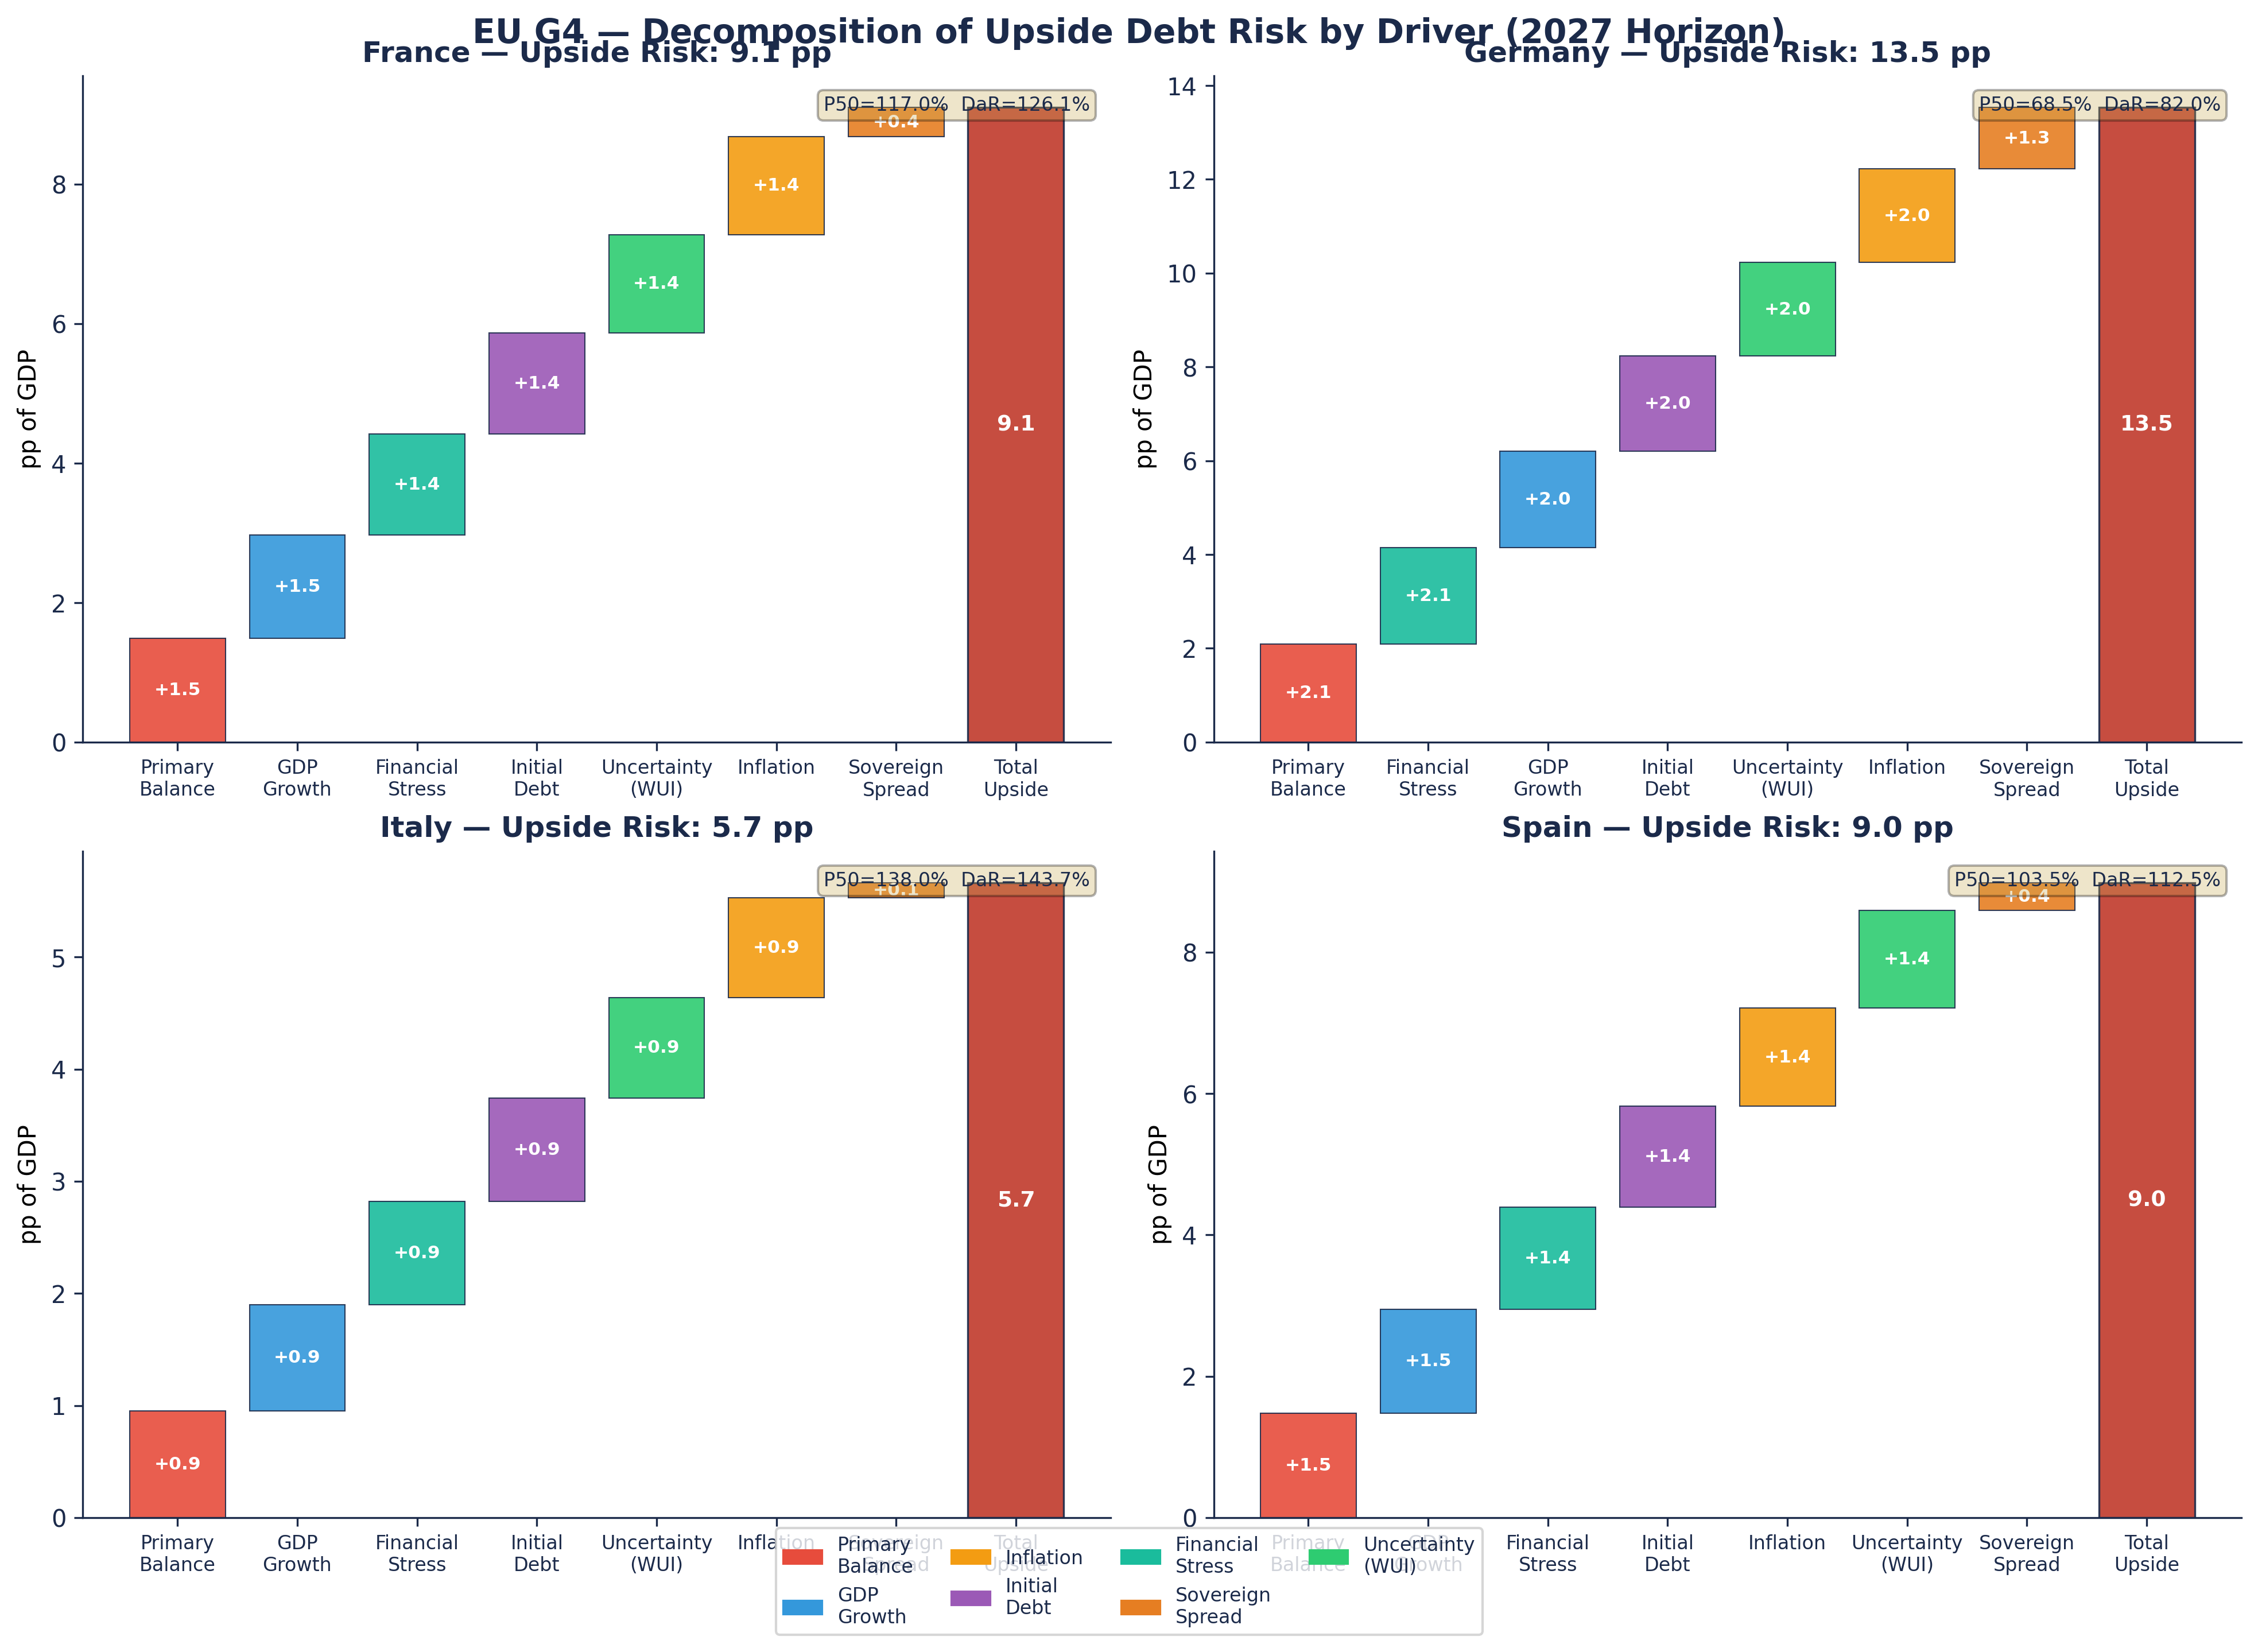

In [ ]:
# Display waterfall
wf_path = chart_paths.get("waterfall")
if wf_path and wf_path.exists():
    display(Image(filename=str(wf_path), width=950))


## Build PowerPoint Deck

In [ ]:
from output.deck import build_deck

deck_path = build_deck(dar, pooled, chart_paths)
print(f"\nDeck saved to: {deck_path}")


## Summary — EU G4 Debt-at-Risk Results

| Country | WEO Baseline | Median (P50) | DaR (P95) | Upside | Downside |
|---------|-------------|-------------|-----------|--------|----------|


In [ ]:
summary = dar[["iso3","weo_baseline","Q50","DaR","Upside","Downside"]].copy()
summary.columns = ["Country","WEO Baseline","Median (P50)","DaR (P95)","Upside (+pp)","Downside (−pp)"]
summary["Country"] = summary["Country"].map(
    {"FRA":"France","DEU":"Germany","ITA":"Italy","ESP":"Spain"}
)
print(summary.to_string(index=False))


Country  WEO Baseline  Median (P50)  DaR (P95)  Upside (+pp)  Downside (−pp)
 France         117.0         117.0     126.11          9.11           11.59
Germany          68.5          68.5      82.01         13.51           19.58
  Italy         138.0         138.0     143.66          5.66            7.21
  Spain         103.5         103.5     112.47          8.97           11.41
